# QCrank Encoding Python Version for Audio

This notebook demonstrates how a short, one-dimensional (single-channel) audio signal with amplitudes in
$[-1,1]$ can be encoded into a quantum state using a uniformly controlled
$R_y$ circuit. It then decodes the ideal statevector and compares the reconstructed
samples with the original signal.

> **Academic Acknowledgement**  
> QCrank was introduced by **Jan Balewski, Mercy G. Amankwah, Roel Van Beeumen,
> E. Wes Bethel, Talita Perciano, and Daan Camps** in *Quantum-parallel vectorized data
> encodings and computations on trapped-ion and transmon QPUs*, *Scientific Reports*
> **14**, 3435 (2024). DOI: [10.1038/s41598-024-53720-x](https://doi.org/10.1038/s41598-024-53720-x).
>
> **Software Acknowledgement**  
> Parts of the Fast Walsh–Hadamard transform, Gray-code circuit decomposition, and
> zero-rotation/CNOT-cancellation logic in this notebook were adapted from the
> [HeidelbergQuantum/QPIXL_ITU-2025](https://github.com/HeidelbergQuantum/QPIXL_ITU-2025)
> repository by Daniel Bultrini and modified for this audio example.

## 1. Introduction: QCrank encoding state and workflow

- For each audio sample $x_j\in[-1,1]$, the notebook defines the logical rotation angle $\phi_j=\frac{\pi}{2}(x_j+1),$ which maps $[-1,1]\mapsto [0,\pi]$

- For $N=2^{n_a}$ samples, the circuit uses:
    - one **data qubit**, $q_0$;
    - $n_a=\log_2N$ **address qubits**.

- The intended encoded state is

$$
|\psi\rangle=
\frac{1}{\sqrt{N}}
\sum_{j=0}^{N-1}
\left[
\cos\left(\frac{\phi_j}{2}\right)|0\rangle+
\sin\left(\frac{\phi_j}{2}\right)|1\rangle
\right]|j\rangle.
$$

- The notebook follows this sequence:

1. Generate a toy audio signal
2. Map its samples to logical $R_y$ angles
3. Transform those angles into uniformly controlled-rotation coefficients
4. Construct and simulate the circuit
5. Recover the angles from ideal probabilities
6. Map the angles back to audio amplitudes
7. Compare the original and decoded signals

**NOTE:** the logical angles $\phi_j$ are not generally the individual
$R_y$ angles visible in the decomposed circuit. The visible rotations are transformed
coefficients whose signed combinations reproduce the logical angles for each address.


## 2. Imports


In [11]:
# Numerical arrays and mathematical operations
import numpy as np

# Plotting the original and reconstructed signals
import matplotlib.pyplot as plt

# Notebook display helper for the Matplotlib circuit drawing
from IPython.display import display

# Qiskit circuit construction and exact statevector simulation
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Audio playback in Jupyter notebooks
from IPython.display import Audio


## 3. Classical preprocessing functions

### 3.1 Binary functions


In [12]:
def is_power_of_two(n): # Checks if the signal length is power of two
    """Return True when ``n`` is a positive integer power of two."""
    # A positive power of two contains exactly one set/activated bit. Clearing its lowest set bit with n & (n - 1) therefore produces zero. 
    # Example: 8 = 1000, 8 - 1 = 7 = 0111, and 8 & 7 = 0. 
    # Bitwise AND (&): 11=1; 10,01,00=0).
    return n > 0 and (n & (n - 1)) == 0


def gray_code(value): # Converts a non-negative integer to its binary-reflected Gray-code representation
    """Return the binary-reflected Gray code of a non-negative integer."""
    # g(i) = i XOR (i shifted right by one bit). Consecutive Gray-code words differ in exactly one bit: 00->01->11->10 = 0->1->3->2. 
    # Example: g(2) = 2 ^ (2 >> 1) = 2 ^ 1 = 3. 
    # Bitwise XOR (^): 11,00=0; 10,01=1.
    return value ^ (value >> 1)


def count_trailing_zeros(value): # Returns the index of the least-significant set/activated bit in a positive integer
    """Return the index of the least-significant set bit in ``value``."""
    if value <= 0:
        raise ValueError("value must be a positive integer")
    # value & -value isolates the least-significant set/activated bit. Its bit length, minus one, gives the zero-based bit position.
    # Example: value = 12 = 1100, -value = -12 = 0100 (two's complement), value & -value = 0100, bit_length() = 3, so index = 2.
    return (value & -value).bit_length() - 1


### 3.2 Scaled Fast Walsh–Hadamard transform and Gray permutation

Let $\boldsymbol{\phi}$ denote the vector of desired logical angles. The decomposition
uses a scaled Walsh–Hadamard transform, followed by a Gray-code permutation, to obtain
the elementary circuit coefficients. With the normalization used below,

$$
\boldsymbol{\alpha}=\frac{1}{N}H_N\boldsymbol{\phi}
$$

before the Gray-code reordering. Compression, when requested, is applied to these
transformed coefficients rather than directly to the audio samples.


In [13]:
def scaled_fwht(values): 
    """
    Apply a scaled Fast Walsh-Hadamard Transform to a copy of ``values``.

    Each butterfly maps (x, y) to ((x + y)/2, (x - y)/2). For an input of
    length N, the repeated factor of 1/2 produces the overall 1/N scaling.
    """
    transformed = np.asarray(values, dtype=float).copy()
    n = transformed.size

    if not is_power_of_two(n):
        raise ValueError("The transform length must be a positive power of two.")

    # ``step`` is the separation between the two entries of each butterfly.
    step = 1
    while step < n:
        # Process independent blocks of length 2 * step.
        for start in range(0, n, 2 * step):
            for offset in range(step):
                left = start + offset
                right = left + step

                # Save both inputs before overwriting either array element.
                x = transformed[left]
                y = transformed[right]

                # Scaled Walsh-Hadamard butterfly.
                transformed[left] = (x + y) / 2.0
                transformed[right] = (x - y) / 2.0

        # Double the butterfly separation for the next transform stage.
        step *= 2

    return transformed


def gray_permutation(values):
    """Return ``values`` reordered by binary-reflected Gray-code indices."""
    values = np.asarray(values)

    # At sequential position i, read the coefficient indexed by gray_code(i).
    return np.array(
        [values[gray_code(i)] for i in range(values.size)],
        dtype=values.dtype,
    )


## 4. Audio-to-angle conversion

The audio samples are linearly mapped from the range $x\in[-1,1]$ to rotation angles $\phi\in[0,\pi]$ using $\phi=\frac{\pi}{2}(x+1), x=\frac{2\phi}{\pi}-1.$

This interval is chosen so that each audio sample corresponds to a unique measurement probability and can therefore be recovered without ambiguity. Negative samples are represented by angles below $\pi/2$, zero corresponds to $\pi/2$, and positive samples are represented by angles above $\pi/2$: $\quad -1\mapsto 0, \quad 0\mapsto\frac{\pi}{2}, \quad 1\mapsto\pi.$



In [14]:
def audio_to_angles(audio):
    """Map finite audio amplitudes in [-1, 1] to RY angles in [0, pi]."""
    audio = np.asarray(audio, dtype=float)

    # Reject invalid floating-point values before constructing the circuit.
    if np.any(~np.isfinite(audio)):
        raise ValueError("The audio signal contains NaN or infinite values.")

    # Do not silently clip or rescale: the caller must supply normalized audio.
    if np.any((audio < -1.0) | (audio > 1.0)):
        raise ValueError("Every audio sample must lie in [-1, 1].")

    return (audio + 1.0) * np.pi / 2.0


def angles_to_audio(angles):
    """Apply the inverse map from RY angles in [0, pi] to [-1, 1]."""
    angles = np.asarray(angles, dtype=float)
    return 2.0 * angles / np.pi - 1.0


## 5. QCrank circuit construction

The address register is first placed in a uniform superposition. A Gray-code sequence of
$R_y$ gates and CNOTs then implements the address-dependent logical rotations.

- Register convention:

    - `q0`: signal/data qubit;
    - `q1, ..., qn`: address qubits;
    - `q0` is Qiskit's least-significant qubit in the statevector basis ordering.

- Optional compression:

The `compression` argument specifies the percentage of the smallest absolute
transformed coefficients to replace by zero. A zero-angle rotation is the identity, and
adjacent CNOTs can then cancel. Compression therefore reduces gates while retaining the
same number of samples and qubits.


In [15]:
def _control_index(step_index, number_of_address_qubits):
     # Determine which address qubit should control the next CNOT gate. Consecutive Gray-code states differ in exactly one bit, so this function identifies the bit that changes and maps it to the corresponding address qubit.

     # The addresses need to be in Gray code so that the CNOTs can be applied in a single pass through the coefficients. The Gray-code ordering ensures that only one address qubit changes at each step, allowing for efficient circuit construction.

    """Return the address-control index for one Gray-code transition."""
    # There are 2**number_of_address_qubits transformed coefficients.
    final_index = (1 << number_of_address_qubits) - 1

    # Close the cyclic Gray-code path after the final coefficient.
    if step_index == final_index:
        return 0

    # Consecutive Gray words differ in exactly one bit. XOR isolates that bit.
    changed_bit = gray_code(step_index) ^ gray_code(step_index + 1)

    # Reverse the bit position to match the address-qubit ordering used below.
    return (
        number_of_address_qubits
        - count_trailing_zeros(changed_bit)
        - 1
    )


def build_qcrank(audio_signal, compression=0.0):
    """
    Build a compressed, uniformly controlled RY encoding of a 1D audio signal.

    Parameters
    ----------
    audio_signal : array-like
        One-dimensional finite samples in [-1, 1]. The length must be a
        positive power of two.
    compression : float, default=0
        Percentage, from 0 to 100, of the smallest absolute transformed
        coefficients to set to zero.

    Returns
    -------
    QuantumCircuit
        A circuit containing one signal qubit (q0), followed by the address
        qubits (q1, q2, ...).

    Notes
    -----
    The audio-derived ``target_angles`` are the desired logical rotations.
    The individual RY gates placed in the circuit use Walsh-Hadamard-transformed,
    Gray-permuted coefficients; they are not generally equal to the target angles.
    """
    audio_signal = np.asarray(audio_signal, dtype=float)

    # This notebook encodes one scalar sample per address, so the input must be 1D.
    if audio_signal.ndim != 1:
        raise ValueError("audio_signal must be one-dimensional.")

    n = audio_signal.size

    # N = 2**n_address is required for a complete binary address register.
    if not is_power_of_two(n):
        raise ValueError("The signal length must be a positive power of two.")

    if not 0.0 <= compression <= 100.0:
        raise ValueError("compression must lie between 0 and 100.")

    number_of_address_qubits = n.bit_length() - 1

    # Step 1: convert normalized audio samples into desired logical RY angles.
    target_angles = audio_to_angles(audio_signal)

    # Step 2: obtain the elementary rotation coefficients required by the
    # Gray-code uniformly controlled-rotation decomposition.
    coefficients = gray_permutation(scaled_fwht(target_angles))

    # Step 3: optionally remove the smallest coefficients by absolute magnitude.
    # This approximates the target state but can reduce the number of RY/CNOT gates.
    number_to_remove = int((compression / 100.0) * n)
    if number_to_remove:
        smallest = np.argsort(np.abs(coefficients))[:number_to_remove]
        coefficients[smallest] = 0.0

    # One signal qubit plus log2(N) address qubits.
    circuit = QuantumCircuit(
        number_of_address_qubits + 1,
        name="QCrank",
    )

    signal_qubit = 0
    address_qubits = range(1, number_of_address_qubits + 1)

    # Prepare an equal superposition of all N sample addresses.
    circuit.h(address_qubits)

    # Apply the Gray-code sequence of rotations and CNOT transitions.
    i = 0
    while i < n:
        # ``parity`` records the net CNOT controls accumulated while zero
        # rotations are skipped. A control used twice cancels because CX^2 = I.
        parity = 0

        # Avoid adding an identity RY(0) operation.
        if not np.isclose(coefficients[i], 0.0):
            circuit.ry(coefficients[i], signal_qubit)

        # Record the Gray-code transition following this coefficient.
        control = _control_index(i, number_of_address_qubits)
        parity ^= 1 << control
        i += 1

        # Skip consecutive zero rotations while retaining only their net CNOT
        # parity. This is the circuit-compression/cancellation step.
        while i < n and np.isclose(coefficients[i], 0.0):
            control = _control_index(i, number_of_address_qubits)
            parity ^= 1 << control
            i += 1

        # Emit only those CNOTs whose controls occur an odd number of times.
        for bit in range(number_of_address_qubits):
            if (parity >> bit) & 1:
                control_qubit = number_of_address_qubits - bit
                circuit.cx(control_qubit, signal_qubit)

    return circuit


## 6. Decoder

For address $j$, the ideal joint probabilities are $p_{0,j}=\frac{1}{N}\cos^2\left(\frac{\phi_j}{2}\right), p_{1,j}=\frac{1}{N}\sin^2\left(\frac{\phi_j}{2}\right).$ The common factor $1/N$ cancels in the angular reconstruction: $\phi_j=2\operatorname{atan2}\left(\sqrt{p_{1,j}},\sqrt{p_{0,j}}\right).$ The factor of two appears because an $R_y(\phi)$ gate stores the parameter through the
half-angle amplitudes $\cos(\phi/2)$ and $\sin(\phi/2)$.


In [16]:
def decode_audio(state):
    """Decode audio amplitudes in [-1, 1] from an ideal QCrank statevector."""
    probabilities = np.asarray(state.probabilities(), dtype=float)

    # Qiskit treats q0 as the least-significant basis bit. Therefore adjacent
    # probabilities correspond to signal-qubit outcomes 0 and 1 at one address:
    #   probabilities[2*j]     -> address j, signal q0 = 0
    #   probabilities[2*j + 1] -> address j, signal q0 = 1
    p0 = np.clip(probabilities[0::2], 0.0, None)
    p1 = np.clip(probabilities[1::2], 0.0, None)

    # Recover the logical RY angle from its half-angle amplitudes. ``arctan2``
    # handles the endpoint cases p0 = 0 or p1 = 0 without division by zero.
    angles = 2.0 * np.arctan2(np.sqrt(p1), np.sqrt(p0))

    # Convert angles in [0, pi] back to normalized audio amplitudes.
    return angles_to_audio(angles)


## 7. Generate a toy audio signal

In [17]:
fs = 8000  # Sampling rate in samples per second (Hz)
f = 700    # Sinusoidal frequency in Hz
N = 16     # Number of samples; must be a positive power of two

# Time vector for N samples: t_n = n / fs for n = 0, ..., N - 1.
t = np.arange(N) / fs

# Unit-amplitude sine wave. Its values naturally lie in the required [-1, 1] range.
signal = np.sin(2 * np.pi * f * t)

# Summarize the generated signal segment.
print(f"Number of samples: {len(signal)}")
print(f"Total duration: {len(signal) / fs * 1000:.2f} ms")
print(f"Sampling rate: {fs} Hz")
print(f"Frequency: {f} Hz")

# Play the audio signal
Audio(signal, rate=fs)


Number of samples: 16
Total duration: 2.00 ms
Sampling rate: 8000 Hz
Frequency: 700 Hz


## 8. Encode, simulate, and decode

In [18]:
# Construct the QCrank circuit.
circuit = build_qcrank(signal, compression=0.0)

# Simulate the complete ideal pure state; no measurements or finite shots are used.
state = Statevector.from_instruction(circuit)

# Recover one normalized audio amplitude for every address state.
decoded_signal = decode_audio(state)

# Display the numerical comparison.
print("Original signal:")
print(np.round(signal, 6))

print("\nDecoded signal:")
print(np.round(decoded_signal, 6))

maximum_absolute_error = np.max(np.abs(decoded_signal - signal))
print("\nMaximum absolute error:")
print(f"{maximum_absolute_error:.3e}")


Original signal:
[ 0.        0.522499  0.891007  0.996917  0.809017  0.382683 -0.156434
 -0.649448 -0.951057 -0.97237  -0.707107 -0.233445  0.309017  0.760406
  0.987688  0.92388 ]

Decoded signal:
[ 0.        0.522499  0.891007  0.996917  0.809017  0.382683 -0.156434
 -0.649448 -0.951057 -0.97237  -0.707107 -0.233445  0.309017  0.760406
  0.987688  0.92388 ]

Maximum absolute error:
5.551e-16


## 9. Draw the quantum circuit

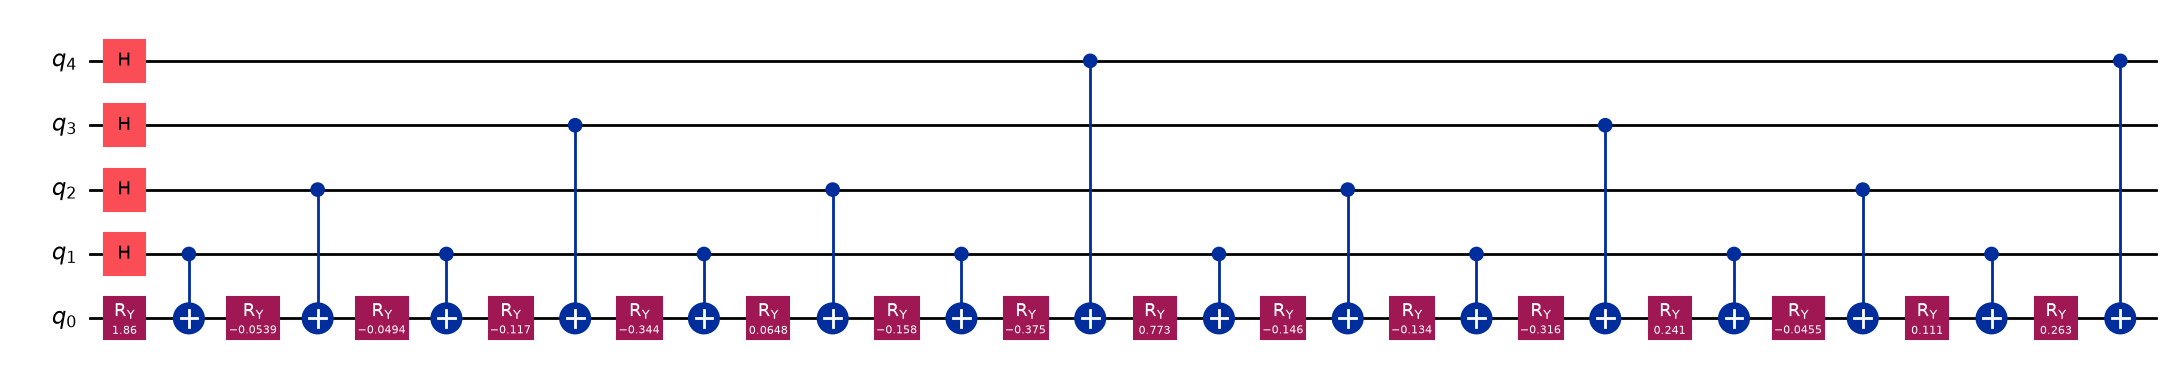

In [19]:
display(
    circuit.draw(
        output="mpl",        # Render as a Matplotlib figure.
        fold=-1,             # Keep the circuit on one horizontal line.
        reverse_bits=True,   # Display q0 at the bottom; computation is unchanged.
    )
)


## 10. Compare the original and decoded signals

For the uncompressed ideal statevector simulation, the two curves should overlap. Raising
the compression percentage will generally reduce circuit gates but introduce
reconstruction error.


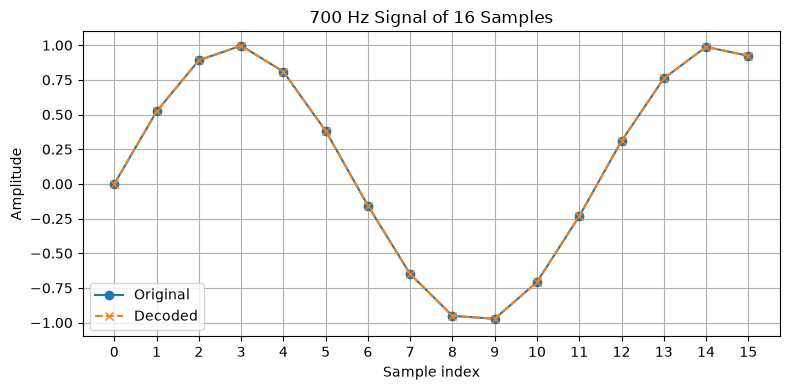

In [20]:
# Use integer sample positions on the horizontal axis.
sample_indices = np.arange(signal.size)

plt.figure(figsize=(8, 4))
plt.plot(sample_indices, signal, "o-", label="Original")
plt.plot(sample_indices, decoded_signal, "x--", label="Decoded")

plt.title(f"{f} Hz Signal of {N} Samples")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.xticks(sample_indices)
plt.ylim(-1.1, 1.1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 11. Notes

- **Single data qubit:** this notebook implements one channel on one data
  qubit. The original QCrank proposal can use multiple data qubits.
- **Ideal simulation:** decoding uses exact statevector probabilities. Real hardware would
  require measurements, repeated shots, etc.
- **Power-of-two length:** the current implementation requires $N=2^{n_a}$ samples. Other
  lengths would need padding.
- **Compression domain:** compression zeroes small transformed rotation coefficients. It
  does not remove input samples and does not reduce the number of qubits.
- **Probability-based decoding:** the $[0,\pi]$ angle interval is important here because the
  decoder does not retain arbitrary amplitude signs or phases.